<div dir="rtl">
<p>נריץ את התאים לפי הסדר בגרעין Julia 1.12 חדש. תא ההכנה הנתון בוחר את
סביבת הקורס; יש להתקין מראש את התלויות. <a href="../README.md">התקנה
ומפתח</a> · <a href="../solutions-he.md">פתרונות מנומקים</a>.</p>

</div>

In [1]:
# Supplied notebook setup: activate the course environment.
import Pkg
Pkg.activate(normpath(joinpath(pwd(), "..", "..")); io = devnull)
println("Course environment activated.")

Course environment activated.


<div dir="rtl">
<h1 id="הילוכים-אקראיים-כיצד-אקראיות-יוצרת-חוק-דיפוזיה">3. הילוכים
אקראיים: כיצד אקראיות יוצרת חוק דיפוזיה</h1>
<p><strong>הרחבה לבחירה · כ־120–160 דקות.</strong> החומר אינו נבחן, אינו
תנאי להמשך ונפרד מהבונוס. נניח היכרות עם לולאות, וקטורים וממוצעים משבוע
3. הסתברות, ממוצע אנסמבל, דיפוזיה ומשוואה רציפה יילמדו כאן. אין צורך
להגדיר פונקציות.</p>
<h2 id="חלקיק-בלתי-צפוי-וענן-צפוי">3.1 חלקיק בלתי צפוי וענן צפוי</h2>
<p>טיפת צבע מתפשטת אף שאיננו עוקבים אחר כל התנגשות מולקולרית. גם חלקיק
מיקרוסקופי מרחף משוטט עקב פגיעות לא סדירות של מולקולות הנוזל. האם מודל
עם צעדים בלתי צפויים יכול בכל זאת לחזות את רוחב הענן?</p>
<p>נתחיל בהילוך חד־ממדי פשוט במכוון. אין זו הדמיה מילולית של כל פגיעה
מולקולרית, אלא מודל להעתק מצטבר במשך פרק זמן נבחר. הוא מועיל כאשר
הזיכרון הכיווני דעך והסביבה אחידה בקירוב.</p>
<blockquote class="physics" style="background:#f4eff9;border:0;border-inline-start:5px solid #8c69ab;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>פיזיקה — המודל הבדיד ותחום תקפותו.</strong> בזמנים <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(t_N=N\Delta t\)</span> החלקיק קופץ ב־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\xi_i=+\ell\)</span> או <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(-\ell\)</span> בהסתברות שווה. ימינה חיובי, <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell&gt;0\)</span> הוא אורך, <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\Delta t&gt;0\)</span> זמן, והמיקום ההתחלתי אפס.
הצעדים בלתי תלויים, ללא הטיה כיוונית, בתווך אחיד ובלתי מוגבל. אין
אינטראקציות בין חלקיקים או קירות בולעים. תנועה אינרציאלית בזמנים קצרים,
צעדים מתואמים, סחיפה או כליאה עשויים לפסול את המודל. אחרי צעד יחיד
הממוצע אפס וממוצע ריבוע ההעתק הוא <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell^2\)</span>.</p>
</blockquote>
<h2 id="הסתברות-ותוחלת-מן-היסוד">3.2 הסתברות ותוחלת מן היסוד</h2>
<p>משתנה מקרי מצמיד מספר לכל תוצאה אפשרית. <strong>תוחלת</strong> היא
ממוצע משוקלל בהסתברויות. לצעד שלנו שתי תוצאות, ולכן</p>
<p><span
style="direction:ltr;unicode-bidi:isolate" class="math display">\[\langle\xi\rangle=\tfrac12\ell+\tfrac12(-\ell)=0,
\qquad\langle\xi^2\rangle=\tfrac12\ell^2+\tfrac12\ell^2=\ell^2.\]</span></p>
<p>הסוגריים הזוויתיים מסמנים ממוצע אידיאלי על חזרות של אותו ניסוי.
<strong>שונות</strong> היא ממוצע ריבוע הסטייה מן התוחלת:</p>
<p><span
style="direction:ltr;unicode-bidi:isolate" class="math display">\[\operatorname{Var}(\xi)=\langle(\xi-\langle\xi\rangle)^2\rangle
=\langle\xi^2\rangle-\langle\xi\rangle^2.\]</span></p>
<p>אי־תלות פירושה שידיעת צעד אחד אינה משנה את ההסתברויות של צעד אחר. היא
נותנת <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\langle\xi_i\xi_j\rangle=\langle\xi_i\rangle\langle\xi_j\rangle=0\)</span>
כאשר <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(i\ne j\)</span>. אי־תלות חזקה יותר
מממוצע אפס: רצף המתחלף באופן דטרמיניסטי ימינה ושמאלה יכול להיות בעל
ממוצע אפס בלי להתפזר.</p>
<p>אחרי <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span> צעדים,</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[x_N=\sum_{i=1}^N\xi_i,\qquad\langle
x_N\rangle=0.\]</span></p>
<p>העלאה בריבוע יוצרת איברים אלכסוניים <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\xi_i^2\)</span> ואיברי מכפלה <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\xi_i\xi_j\)</span>. תוחלת איברי המכפלה מתאפסת,
ולכן</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\boxed{\langle
x_N^2\rangle=N\ell^2.}\]</span></p>
<p>נגדיר מקדם דיפוזיה חד־ממדי <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(D=\ell^2/(2\Delta t)\)</span>, ביחידות אורך בריבוע
חלקי זמן. נקבל</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\boxed{\langle x^2(t)\rangle=2Dt,\qquad
x_{\rm rms}=\sqrt{2Dt}.}\]</span></p>
<blockquote class="mathematics" style="background:#eff6ee;border:0;border-inline-start:5px solid #5f9763;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>מתמטיקה — ממוצע הריבוע אינו ריבוע הממוצע.</strong> <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\langle x^2\rangle\ne\langle x\rangle^2\)</span>
בדרך כלל. לענן סימטרי יכול להיות ממוצע אפס ורוחב הולך וגדל. העתק RMS גדל
כמו <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\sqrt t\)</span>, בעוד שהעתק בליסטי
במהירות קבועה גדל כמו <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(t\)</span>. זמן גדול
פי ארבעה נותן מרחק RMS דיפוזי גדול פי שניים.</p>
</blockquote>
<h2 id="צעד-אקראי-שאפשר-לשחזר">3.3 צעד אקראי שאפשר לשחזר</h2>
<p><code dir="ltr" style="unicode-bidi:isolate">Random</code> מספק דגימות אקראיות, ו־<code dir="ltr" style="unicode-bidi:isolate">StableRNGs</code>
מחולל עם זרם הניתן לשחזור בממשק המתועד שלו. <code dir="ltr" style="unicode-bidi:isolate">StableRNG(seed)</code>
יוצר מחולל מקומי; המספר השלם מזהה מצב התחלתי. שימוש באותו זרע בתחילת
ניסוי שלם משחזר אותו. יצירת המחולל מחדש בכל צעד תחזור על אותה דגימה
ותהרוס את אי־התלות. <code dir="ltr" style="unicode-bidi:isolate">Statistics</code> מספק <code dir="ltr" style="unicode-bidi:isolate">mean</code>
ו־<code dir="ltr" style="unicode-bidi:isolate">var</code>; יתר ההכנה מיועדת לשרטוט ולעיצוב הפלט.</p>

</div>

In [2]:
using Plots
using Printf
using Random
using StableRNGs
using Statistics
gr()
default(size = (760, 420), linewidth = 2, legend = :topleft)
println("Independent one-dimensional walks; lengths in micrometres, time in seconds.")

Independent one-dimensional walks; lengths in micrometres, time in seconds.


<div dir="rtl">
<p><code dir="ltr" style="unicode-bidi:isolate">rand(rng)</code> נותן מספר פסאודו־אקראי בין אפס לאחד. ערך קטן
מ־0.5 בוחר שמאלה וכל ערך אחר ימינה. שוויון אורכי שני התחומים נותן
הסתברויות שוות. הדוגמה הקטנה מאפשרת לבדוק החלטה אחת לפני שחוזרים עליה
פעמים רבות.</p>

</div>

In [3]:
rng = StableRNG(77641)
draw = rand(rng)
ell_um = 1.0
if draw < 0.5
    jump_um = -ell_um
else
    jump_um = ell_um
end
@printf("Uniform draw = %.6f; step = %.1f micrometres\n", draw, jump_um)

Uniform draw = 0.259876; step = -1.0 micrometres


<div dir="rtl">
<p>מחשב משתמש באלגוריתם דטרמיניסטי כדי לחקות דגימות בלתי תלויות. זרע
קבוע מועיל לאיתור שגיאות; הוא אינו הופך מדגם סופי לתוחלת המתמטית. בהמשך
נחשב גם את גודל התנודות הצפויות במדגם.</p>
<h2 id="מסלול-יחיד">3.4 מסלול יחיד</h2>
<p><code dir="ltr" style="unicode-bidi:isolate">zeros(N + 1)</code> שומר מקום לנקודת ההתחלה ול־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span> מיקומים מאוחרים. משום שהאינדקס הראשון
ב־Julia הוא אחד, <code dir="ltr" style="unicode-bidi:isolate">position_um[k + 1]</code> מחזיק את המיקום אחרי
צעד <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(k\)</span>. כל מיקום הוא קודמו ועוד
קפיצה. הלולאה מממשת את הסכום מן הגזירה בלי לשמור כל קפיצה בנפרד. נבחר
<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell=1\ \mu\)</span>m ו־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\Delta t=0.1\)</span> שניות, ולכן <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(D=5\ \mu\mathrm{m}^2/\mathrm{s}\)</span>.</p>

</div>

Final position = 22.0 micrometres after 20.0 seconds


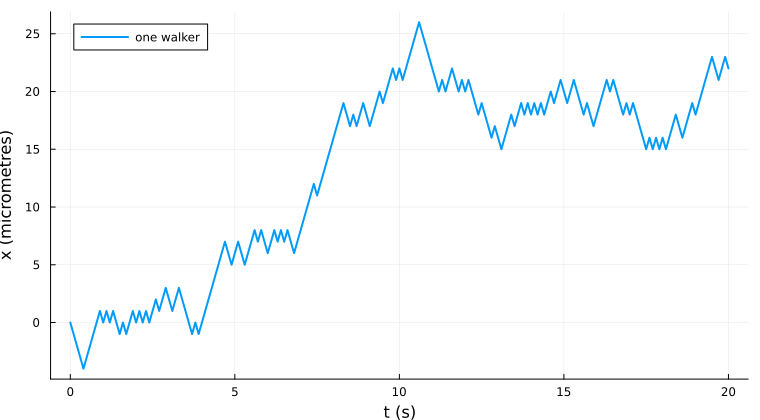

In [4]:
rng = StableRNG(77641)
N = 200
dt_s = 0.1
position_um = zeros(N + 1)
for k in 1:N
    if rand(rng) < 0.5
        jump_um = -ell_um
    else
        jump_um = ell_um
    end
    position_um[k + 1] = position_um[k] + jump_um
end
time_s = (0:N) .* dt_s
@printf("Final position = %.1f micrometres after %.1f seconds\n", position_um[end], time_s[end])
display(plot(time_s, position_um; label = "one walker", xlabel = "t (s)", ylabel = "x (micrometres)"))

<div dir="rtl">
<p>הקטעים מחברים מיקומים בזמנים בדידים; מודל הקפיצות אינו קובע מהירות
פיזיקלית לאורך הקווים. ההעתק הסופי אינו חייב להיות אפס. גם <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(x(t)^2\)</span> של מסלול יחיד אינו אמור לעקוב
בצורה חלקה אחרי <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(2Dt\)</span>: החוק מתייחס
לממוצע על חזרות.</p>
<h2 id="אנסמבל-עותקים-רבים-של-אותו-ניסוי">3.5 אנסמבל: עותקים רבים של
אותו ניסוי</h2>
<p>נפתח <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M=10000\)</span> הילוכים בלתי
תלויים. וקטור מחזיק את מיקומיהם הנוכחיים. הלולאה החיצונית מקדמת זמן,
והפנימית מעדכנת כל חלקיק פעם אחת. אחרי כל עדכון נשמור</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\bar x_N=\frac1M\sum_{j=1}^M
x_N^{(j)},\qquad
\widehat{\mathrm{MSD}}_N=\frac1M\sum_{j=1}^M(x_N^{(j)})^2.\]</span></p>
<p>האינדקס העליון מסמן חלקיק ולא חזקה. <code dir="ltr" style="unicode-bidi:isolate">positions_um .^ 2</code>
מעלה כל איבר בריבוע לפני המיצוע. <code dir="ltr" style="unicode-bidi:isolate">eachindex</code> עובר על כל
האינדקסים התקפים. נשמור רק שני וקטורי זמן ואת המיקומים הנוכחיים, ולא
מטריצה גדולה של כל המסלולים. <code dir="ltr" style="unicode-bidi:isolate">[msd_um2 theory_um2]</code> מספק שתי
עמודות לשרטוט; זו עזרת שרטוט נתונה ולא תרגיל ליבה במטריצות.</p>
<p>כדי לשפוט התאמה לתיאוריה נחשב תחילה את שגיאת התקן. מאי־תלות בין
החלקיקים,</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\mathrm{SE}(\bar
x_N)=\ell\sqrt{N/M}.\]</span></p>
<p>לממוצע הריבוע דרוש מומנט רביעי. בפיתוח <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(x_N^4\)</span> שורדים רק איברים שבהם כל צעד בלתי
תלוי בעל תוחלת אפס מופיע בחזקה זוגית. יש <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span> איברים עם ארבעה אינדקסים שווים ועוד
<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(6\binom N2\)</span> איברי זוגות. לכן</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\langle x_N^4\rangle=(3N^2-2N)\ell^4,
\qquad\operatorname{Var}(x_N^2)=2N(N-1)\ell^4,\]</span></p>
<p>ומיצוע על <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M\)</span> חלקיקים נותן</p>
<p><span
style="direction:ltr;unicode-bidi:isolate" class="math display">\[\mathrm{SE}(\widehat{\mathrm{MSD}}_N)=\ell^2\sqrt{\frac{2N(N-1)}{M}}.\]</span></p>
<p>עבור <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N=200\)</span>, ממוצע הריבוע הצפוי
הוא <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(200\ \mu\mathrm{m}^2\)</span> ושגיאת
התקן שלו כ־<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(2.82\ \mu\mathrm{m}^2\)</span>.
נדרוש הסכמה סטטיסטית ולא שוויון מדויק.</p>

</div>

D = 5.00 micrometres^2/s
Final ensemble mean = 0.0062 micrometres; theoretical SE = 0.1414


Final MSD = 202.6884 micrometres^2; theory = 200.0000; SE = 2.8213


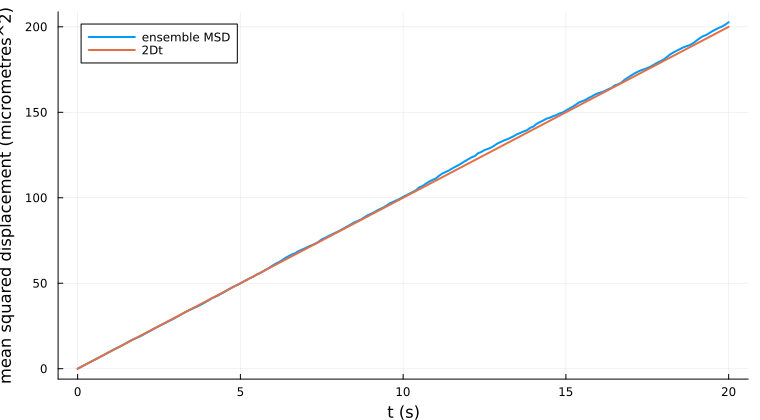

In [5]:
rng = StableRNG(314159)
M = 10000
positions_um = zeros(M)
mean_um = zeros(N + 1)
msd_um2 = zeros(N + 1)
for k in 1:N
    for j in eachindex(positions_um)
        if rand(rng) < 0.5
            positions_um[j] = positions_um[j] - ell_um
        else
            positions_um[j] = positions_um[j] + ell_um
        end
    end
    mean_um[k + 1] = mean(positions_um)
    msd_um2[k + 1] = mean(positions_um .^ 2)
end
D_um2_s = ell_um^2 / (2 * dt_s)
theory_um2 = 2 .* D_um2_s .* time_s
se_mean_um = ell_um * sqrt(N / M)
se_msd_um2 = ell_um^2 * sqrt(2 * N * (N - 1) / M)
@printf("D = %.2f micrometres^2/s\n", D_um2_s)
@printf("Final ensemble mean = %.4f micrometres; theoretical SE = %.4f\n", mean_um[end], se_mean_um)
@printf("Final MSD = %.4f micrometres^2; theory = %.4f; SE = %.4f\n", msd_um2[end], theory_um2[end], se_msd_um2)
display(plot(time_s, [msd_um2 theory_um2]; label = ["ensemble MSD" "2Dt"],
    xlabel = "t (s)", ylabel = "mean squared displacement (micrometres^2)"))

<div dir="rtl">
<p>העקומה אמורה להתנודד סביב הישר. היא עדיין אקראית, גם אם ההבדל כמעט
אינו נראה. הגדלת מספר החלקיקים פי ארבעה אמורה להקטין את גודל השגיאות
האופייני פי שניים. הגדלת מספר הצעדים לבדה אינה מוסיפה חלקיקים בלתי
תלויים.</p>
<blockquote class="check" style="background:#fff4e7;border:0;border-inline-start:5px solid #d98538;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>בדיקה — נקודות זמן מתואמות.</strong> ערכי MSD בזמנים עוקבים
משתמשים באותם חלקיקים ובאותה היסטוריה. שגיאותיהם מתואמות. התאמת ישר
המתייחסת לכל זמן כאל תצפית בלתי תלויה תיתן אי־ודאות מטעה. ישר עשוי
להועיל כתיאור; חזרות בלתי תלויות על אנסמבל שלם מועילות יותר להערכת
אי־הוודאות בשיפוע.</p>
</blockquote>
<h2 id="מדוע-ההתפלגות-נעשית-גאוסית">3.6 מדוע ההתפלגות נעשית גאוסית?</h2>
<p>אם <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(r\)</span> מתוך <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span> הצעדים ימינה, אז <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(x=(2r-N)\ell\)</span>. יש <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\binom Nr\)</span> אפשרויות לבחור אותם, לכל אחת
הסתברות <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(2^{-N}\)</span>:</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[P\{x_N=(2r-N)\ell\}=\binom
Nr2^{-N}.\]</span></p>
<p>עבור <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span> גדול, סכום תוספות חסומות
ובלתי תלויות נותן בקירוב התפלגות גאוסית במרכז. השונות היא <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\ell^2=2Dt\)</span>, ולכן צפיפות הרצף היא</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[p(x,t)=\frac1{\sqrt{4\pi
Dt}}\exp\left(-\frac{x^2}{4Dt}\right),\qquad t&gt;0.\]</span></p>
<p>לצפיפות יחידות אורך הפוך; האינטגרל שלה, לא גובהה, הוא הסתברות. יש גם
עדינות בדידה: אחרי מספר זוגי של צעדים, רק כפולות זוגיות של <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell\)</span> נגישות. המרווח בין מיקומים אפשריים
הוא <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(2\ell\)</span>. להשוואה עם צפיפות נחלק
כל ספירה ב־<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M(2\ell)\)</span>.</p>
<p>הקוד סופר מיקומים אפשריים. <code dir="ltr" style="unicode-bidi:isolate">zeros(Int, ...)</code> יוצר מונים
שלמים. המיפוי ההפוך ממיקום לאינדקס תא משתמש
ב־<code dir="ltr" style="unicode-bidi:isolate">round(Int, ...)</code> לקבלת אינדקס שלם. <code dir="ltr" style="unicode-bidi:isolate">+= 1</code> מוסיף
אחד. <code dir="ltr" style="unicode-bidi:isolate">bar</code> מציג עמודות ו־<code dir="ltr" style="unicode-bidi:isolate">plot!</code> מוסיף את תחזית
הרצף. נציג רק את האזור המרכזי, אך ננרמל בעזרת <strong>כל</strong> נקודות
הסיום.</p>

</div>

Discrete histogram integral = 1.000000


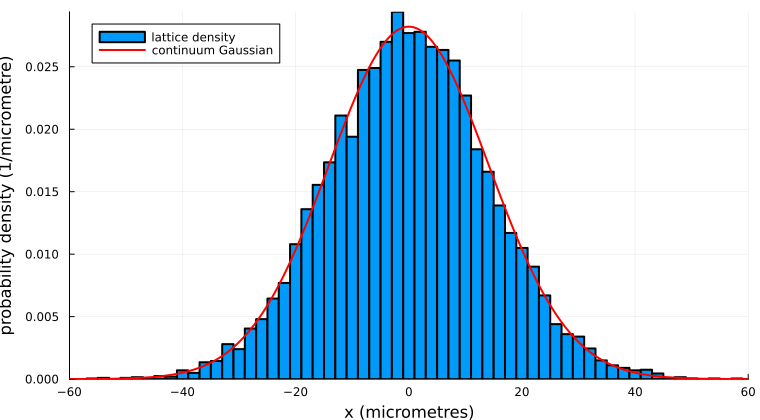

In [6]:
centers_um = collect(-N:2:N) .* ell_um
counts = zeros(Int, length(centers_um))
for value in positions_um
    index = round(Int, (value / ell_um + N) / 2) + 1
    counts[index] += 1
end
density_per_um = counts ./ (M * 2 * ell_um)
grid_um = range(-60.0, 60.0; length = 1001)
t_final_s = N * dt_s
gaussian_per_um = exp.(-grid_um .^ 2 ./ (4 * D_um2_s * t_final_s)) ./ sqrt(4pi * D_um2_s * t_final_s)
@printf("Discrete histogram integral = %.6f\n", sum(density_per_um) * 2 * ell_um)
p_dist = bar(centers_um, density_per_um; bar_width = 2 * ell_um, label = "lattice density",
    xlabel = "x (micrometres)", ylabel = "probability density (1/micrometre)", xlim = (-60, 60))
plot!(p_dist, grid_um, gaussian_per_um; label = "continuum Gaussian", color = :red)
display(p_dist)

<div dir="rtl">
<p>העמודות אינן חייבות לחפוף לגאוסיאן. <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M\)</span> סופי יוצר תנודות דגימה; <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span> סופי משאיר סריג; לגאוסיאן זנבות מעבר
לגבול המדויק של ההילוך <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(|x|\leq
N\ell\)</span>. הקירוב שימושי במיוחד באזור המרכזי אחרי צעדים רבים.</p>
<h2 id="מהילוך-למשוואה-דיפרנציאלית">3.7 מהילוך למשוואה דיפרנציאלית</h2>
<p>תהי <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(p(x,t)\)</span> צפיפות חלקה בקירוב על
סקלות גדולות מאורך הצעד. כדי להגיע ל־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(x\)</span> בצעד הבא, החלקיק צריך להגיע מ־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(x-\ell\)</span> בצעד ימינה או מ־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(x+\ell\)</span> בצעד שמאלה. שימור הסתברות נותן</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[p(x,t+\Delta
t)=\tfrac12p(x-\ell,t)+\tfrac12p(x+\ell,t).\]</span></p>
<p>פיתוח טיילור מקרב ערכים סמוכים באמצעות נגזרות בנקודה הנוכחית. בסדרים
המובילים אגף שמאל הוא <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(p+\Delta t\,\partial_t
p\)</span>, ואגף ימין <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(p+(\ell^2/2)\partial_x^2p\)</span>: הנגזרות
המרחביות האי־זוגיות מתבטלות. נחסר <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(p\)</span>
ונחלק ב־<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\Delta t\)</span>:</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\boxed{\frac{\partial p}{\partial
t}=D\frac{\partial^2p}{\partial x^2}.}\]</span></p>
<p><strong>משוואת הדיפוזיה</strong> מתארת צפיפות מקרוסקופית. היא אינה
אומרת שמסלול של חלקיק יחיד גזיר. הגאוסיאן פותר אותה על ישר אינסופי עבור
הסתברות יחידה המרוכזת בתחילה בנקודה, והאינטגרל שלו אחד. ענן התחלתי סופי
מתפשט לפי קונבולוציה עם גאוסיאן זה, כלומר סכום משוקלל של פתרונות
נקודתיים ממיקומי ההתחלה.</p>
<blockquote class="mathematics" style="background:#eff6ee;border:0;border-inline-start:5px solid #5f9763;padding:.5em 1.2em;margin:1.5em 0">
<p><strong>מתמטיקה — בגבול הרצף שומרים על <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(D\)</span>.</strong> הקטנת אורך הצעד וזמן הצעד
באופן שרירותי משנה את הפיזיקה. כדי לחצות את <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell\)</span> ולשמור על <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(D\)</span> צריך לחלק את <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\Delta t\)</span> בארבע. הגבול משתמש בצעדים קטנים
ורבים עם יחס קבוע <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell^2/(2\Delta
t)\)</span> וצפיפות המשתנה לאט לאורך צעד יחיד. בזמן אפס הצפיפות הנקודתית
האידיאלית סינגולרית; אין להציב <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(t=0\)</span>
בנוסחת הגאוסיאן.</p>
</blockquote>
<h2 id="אמידת-דיפוזיה-והוספת-סחיפה">3.8 אמידת דיפוזיה והוספת סחיפה</h2>
<p>בזמן חיובי קבוע אפשר לאמוד את <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(D\)</span>
באמצעות <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\widehat{\mathrm{MSD}}/(2t)\)</span>
ולהעביר לאומד את שגיאת התקן של ממוצע הריבוע. האומד חסר הטיה בהילוך שלנו,
ללא הטיה ומראשית אפס. הוא אינו מתאים אוטומטית למדידות עם שגיאה או לחלקיק
תחת כוח.</p>
<p>אם ההסתברות לצעד ימינה היא <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(p_r\)</span>,
אז</p>
<p><span
style="direction:ltr;unicode-bidi:isolate" class="math display">\[\mu_\xi=(2p_r-1)\ell,\qquad\sigma_\xi^2=4p_r(1-p_r)\ell^2.\]</span></p>
<p>מהירות הסחיפה היא <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(v=\mu_\xi/\Delta
t\)</span> ומקדם הדיפוזיה סביב הממוצע <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(D_{\rm
bias}=\sigma_\xi^2/(2\Delta t)\)</span>. לכן</p>
<p><span style="direction:ltr;unicode-bidi:isolate" class="math display">\[\langle
x\rangle=vt,\quad\operatorname{Var}(x)=2D_{\rm bias}t,
\quad\langle x^2\rangle=2D_{\rm bias}t+(vt)^2.\]</span></p>

</div>

In [7]:
D_endpoint = msd_um2[end] / (2 * t_final_s)
se_D = se_msd_um2 / (2 * t_final_s)
@printf("Endpoint D estimate = %.4f +/- %.4f micrometres^2/s (one theoretical SE)\n", D_endpoint, se_D)
p_right = 0.6
mean_step_um = (2 * p_right - 1) * ell_um
variance_step_um2 = 4 * p_right * (1 - p_right) * ell_um^2
drift_um_s = mean_step_um / dt_s
D_biased = variance_step_um2 / (2 * dt_s)
@printf("Biased walk: drift = %.2f micrometres/s; D = %.2f micrometres^2/s\n", drift_um_s, D_biased)
@printf("At t = %.1f s: mean = %.1f; variance = %.1f; raw second moment = %.1f\n",
    t_final_s, N * mean_step_um, N * variance_step_um2,
    N * variance_step_um2 + (N * mean_step_um)^2)

Endpoint D estimate = 5.0672 +/- 0.0705 micrometres^2/s (one theoretical SE)
Biased walk: drift = 2.00 micrometres/s; D = 4.80 micrometres^2/s
At t = 20.0 s: mean = 40.0; variance = 192.0; raw second moment = 1792.0


<div dir="rtl">
<p>המומנט השני בהילוך מוטה גדל בחלקו כמו <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(t^2\)</span>. פירושו כ־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(2Dt\)</span> בלבד יבלבל סחיפה עם דיפוזיה חזקה
יותר. הערכים המוטים שהודפסו הם תחזיות אנליטיות, לא פלט של הדמיה מוטה;
בחקירה שבהמשך נבדוק אותם בהדמיה נפרדת.</p>
<h2 id="ביקורת-החישוב">3.9 ביקורת החישוב</h2>
<p><code dir="ltr" style="unicode-bidi:isolate">diff</code> מחסר איברים עוקבים ובודק את אורכי הקפיצות.
<code dir="ltr" style="unicode-bidi:isolate">all</code> דורש תנאי בכל איבר.
<code dir="ltr" style="unicode-bidi:isolate">var(...; corrected = false)</code> משתמש במכנה <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M\)</span>, בהתאמה לזהות המדגם <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\overline{x^2}-\bar x^2\)</span>. ברירת המחדל
המתוקנת משתמשת ב־<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M-1\)</span> לאמידה חסרת
הטיה של שונות האוכלוסייה. <code dir="ltr" style="unicode-bidi:isolate">@testset</code> מקבץ בדיקות,
ו־<code dir="ltr" style="unicode-bidi:isolate">isapprox</code> בודק זהויות בנקודה צפה עד סבילות מוחלטת
קטנה.</p>

</div>

In [8]:
using Test
# The final semicolon hides the returned test object; its summary still prints.
@testset "Discrete walk and continuum checks" begin
    @test position_um[1] == 0.0
    @test all(abs.(diff(position_um)) .== ell_um)
    @test all(abs.(positions_um) .<= N * ell_um)
    @test sum(counts) == M
    @test isapprox(sum(density_per_um) * 2 * ell_um, 1.0; atol = 1e-12)
    @test abs(mean_um[end]) < 5 * se_mean_um
    @test abs(msd_um2[end] - N * ell_um^2) < 5 * se_msd_um2
    @test isapprox(mean(positions_um .^ 2) - mean(positions_um)^2,
        var(positions_um; corrected = false); atol = 1e-10)
    @test isapprox((ell_um / 2)^2 / (2 * (dt_s / 4)), D_um2_s; atol = 1e-12)
end;

Test Summary:                      | Pass  

Total  Time
Discrete walk and continuum checks |    9      9  0.2s


<div dir="rtl">
<p>שני גבולות חמש שגיאות התקן הם בדיקות אבחון רחבות לניסוי בעל הזרע
הקבוע; הם אינם חוקים דטרמיניסטיים או הוכחה לאיכות המחולל. בדיקות הנרמול,
אורך הצעד וזהות המומנטים מגלות שגיאות אחרות מאלו שמגלה התאמת ה־MSD
לתיאוריה.</p>
<h2 id="חקירה-מודרכת-ובדיקה-עצמית">3.10 חקירה מודרכת ובדיקה עצמית</h2>
<ol type="1">
<li>נגזור את הסתברויות הסיום אחרי שני צעדים, ונחשב ממוצע, ממוצע ריבוע
ומומנט רביעי. נשווה לנוסחאות הכלליות.</li>
<li>נחזור על האנסמבל עם <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(M=2500\)</span>
ו־<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(10000\)</span> ועם כמה זרעים שונים. נשמור
על <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(N\)</span>, <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell\)</span> ו־<span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\Delta
t\)</span>, ונשווה שגיאות ביחידות שגיאת התקן החזויה במקום לבחור את הריצה
היפה ביותר.</li>
<li>נחצה את <span style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\ell\)</span>, נחלק את <span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\Delta t\)</span> בארבע ונכפיל את מספר הצעדים
בארבע כדי לשמור על הזמן הפיזיקלי הסופי. נשווה את הרוחב ונבחין בין
רזולוציית הסריג לרעש הדגימה.</li>
<li>נממש הסתברות ימינה 0.6 על ידי בחירת שמאלה כאשר ההגרלה קטנה מ־0.4.
נרשום ממוצע, שונות ומומנט שני גולמי ונשווה את שלושתם לתחזיות.</li>
<li>נניח שאיפסנו בטעות את המחולל בכל צעד. ננבא את המסלול ואת תלות ריבוע
ההעתק בזמן ונסביר איזו הנחה בגזירה נשברה.</li>
<li><strong>המשך פתוח:</strong> נוסיף קירות מחזירים ב־<span
style="direction:ltr;unicode-bidi:isolate" class="math inline">\(\pm L\)</span>. נסביר מדוע ממוצע הריבוע אינו יכול
לגדול ליניארית לנצח ואילו תנאי שפה נחוצים במודל הרציף.</li>
</ol>
<p><strong>תוצר ללמידה עצמית:</strong> מסלול יחיד, גרף MSD של אנסמבל,
התפלגות סיום מנורמלת, טבלת זרעים וגדלי אנסמבל ופסקה המבחינה בין שגיאת
מודל, בדידות ותנודות מדגם סופי. קובץ הפתרונות מספק נימוקים וערכי
ייחוס.</p>
<p><strong>סיכום.</strong> תוספות בלתי תלויות בעלות תוחלת אפס נותנות
שונות הגדלה ליניארית בזמן. ממוצעי אנסמבל חושפים חוק המוסתר במימוש יחיד,
ואפשר לכמת את אי־הוודאות שלהם. גבול רצף קושר אלגוריתם אקראי למשוואה
דיפרנציאלית; סחיפה מחייבת להבחין בין שונות למומנט שני גולמי.</p>
<p><strong>לקריאה נוספת:</strong> <a
href="https://docs.julialang.org/en/v1/stdlib/Random/">תיעוד Random
ב־Julia</a>; <a
href="https://github.com/JuliaRandom/StableRNGs.jl">תיעוד
StableRNGs</a>. לתנועה בראונית ולמשוואת הדיפוזיה אפשר לעיין בספר פיזיקה
סטטיסטית; כל המשוואות הנחוצות כאן נגזרו לעיל.</p>

</div>